# Musterloesung — Projekt 03 (final): Einkommensvorhersage auf echten Zensusdaten

Vollstaendig ausgefuehrte Loesung zu `../einkommensvorhersage.ipynb`. Erst selbst versuchen!

## 1. Daten laden & explorieren

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

daten = fetch_openml(name="adult", version=2, as_frame=True)
df = daten.frame

print(df.shape)
print(df.isna().sum()[df.isna().sum() > 0])
print(df["class"].value_counts(normalize=True))

(48842, 15)
workclass         2799
occupation        2809
native-country     857
dtype: int64
class
<=50K    0.760718
>50K     0.239282
Name: proportion, dtype: float64


## 2. Aufbereitung: Zielvariable & Features

In [2]:
y = (df["class"] == ">50K").astype(int)
X = df.drop(columns=["class", "fnlwgt", "education"])

numerische_features = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
kategoriale_features = ["workclass", "marital-status", "occupation", "relationship",
                         "race", "sex", "native-country"]

print(f"Anzahl Features: {len(numerische_features) + len(kategoriale_features)}")
print(y.mean())

Anzahl Features: 12
0.23928176569346055


## 3. Train/Test-Split

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training: {len(X_train)}, Test: {len(X_test)}")
print(abs(y_test.mean() - y.mean()) < 0.01)

Training: 39073, Test: 9769
True


## 4. Preprocessing-Pipeline

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numerisch_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
kategorial_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
vorverarbeitung = ColumnTransformer([
    ("num", numerisch_pipe, numerische_features),
    ("kat", kategorial_pipe, kategoriale_features),
])

print(vorverarbeitung)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['age', 'education-num', 'capital-gain',
                                  'capital-loss', 'hours-per-week']),
                                ('kat',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['workclass', 'marital-status', 'occupation',
                                  'relationship', 'race', 'sex',
                 

## 5. Baseline

In [5]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
print(f"Dummy Accuracy: {dummy.score(X_test, y_test):.3f}  (sagt einfach immer '<=50K')")

Dummy Accuracy: 0.761  (sagt einfach immer '<=50K')


## 6. Modellvergleich unter Klassenungleichgewicht

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelle = {
    "Logistische Regression": Pipeline([("prep", vorverarbeitung),
                                         ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))]),
    "Random Forest": Pipeline([("prep", vorverarbeitung),
                                ("clf", RandomForestClassifier(random_state=42, class_weight="balanced"))]),
    "Gradient Boosting": Pipeline([("prep", vorverarbeitung),
                                    ("clf", HistGradientBoostingClassifier(random_state=42, class_weight="balanced"))]),
}

ergebnisse = {}
for name, pipeline in modelle.items():
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="average_precision", n_jobs=-1)
    ergebnisse[name] = scores

for name, scores in ergebnisse.items():
    print(f"{name:25s}  PR-AUC = {scores.mean():.4f} +/- {scores.std():.4f}")

Logistische Regression     PR-AUC = 0.7613 +/- 0.0114
Random Forest              PR-AUC = 0.7129 +/- 0.0105
Gradient Boosting          PR-AUC = 0.8265 +/- 0.0072


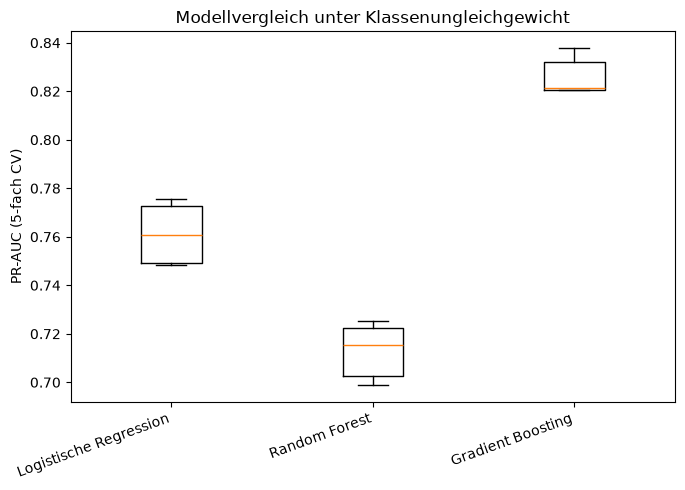

In [7]:
plt.figure(figsize=(7, 5))
plt.boxplot(ergebnisse.values(), tick_labels=ergebnisse.keys())
plt.xticks(rotation=20, ha="right")
plt.ylabel("PR-AUC (5-fach CV)")
plt.title("Modellvergleich unter Klassenungleichgewicht")
plt.tight_layout()
plt.show()

## 7. Tuning des besten Modells

Gradient Boosting liegt meist vorn — hier getunt.

In [8]:
from sklearn.model_selection import GridSearchCV

grid = {
    "clf__max_iter": [100, 200, 300],
    "clf__learning_rate": [0.03, 0.1, 0.2],
    "clf__max_leaf_nodes": [15, 31, 63],
}
suche = GridSearchCV(modelle["Gradient Boosting"], grid, cv=cv, scoring="average_precision", n_jobs=-1)
suche.fit(X_train, y_train)

print(f"Bestes CV-PR-AUC: {suche.best_score_:.4f}")
print(f"Beste Parameter: {suche.best_params_}")

Bestes CV-PR-AUC: 0.8272
Beste Parameter: {'clf__learning_rate': 0.1, 'clf__max_iter': 200, 'clf__max_leaf_nodes': 15}


## 8. Die einmalige Testauswertung

              precision    recall  f1-score   support

       <=50K       0.95      0.82      0.88      7431
        >50K       0.60      0.87      0.71      2338

    accuracy                           0.83      9769
   macro avg       0.78      0.84      0.80      9769
weighted avg       0.87      0.83      0.84      9769

Test-PR-AUC: 0.8293


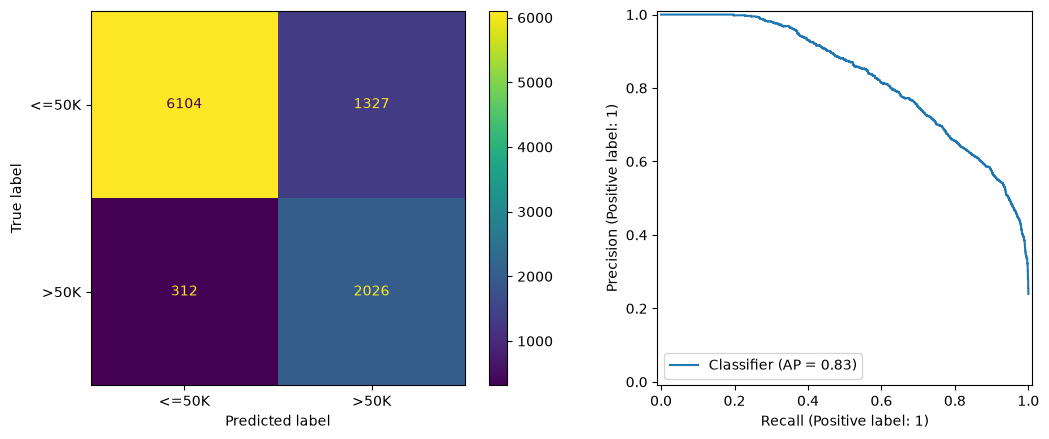

In [9]:
from sklearn.metrics import (classification_report, PrecisionRecallDisplay,
                             average_precision_score, confusion_matrix, ConfusionMatrixDisplay)

bestes_modell = suche.best_estimator_
y_proba = bestes_modell.predict_proba(X_test)[:, 1]
y_pred_05 = (y_proba >= 0.5).astype(int)

print(classification_report(y_test, y_pred_05, target_names=["<=50K", ">50K"]))
print(f"Test-PR-AUC: {average_precision_score(y_test, y_proba):.4f}")

fig, achsen = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_05, display_labels=["<=50K", ">50K"], ax=achsen[0])
PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=achsen[1])
plt.tight_layout()
plt.show()

## 9. Schwellenwahl per Kostenrechnung

Kostenminimale Schwelle: 0.44  (Kosten bei 0.5: 128750 $, minimale Kosten: 124000 $)


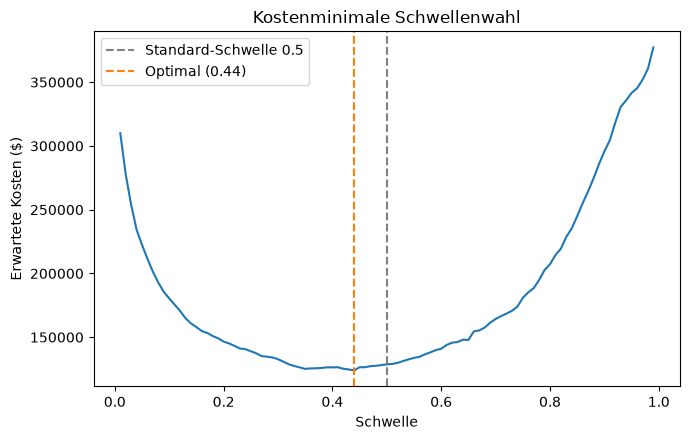

In [10]:
schwellen = np.linspace(0.01, 0.99, 99)
kosten_fp, kosten_fn = 50, 200

y_test_np = y_test.to_numpy()
kosten = []
for t in schwellen:
    y_pred_t = (y_proba >= t).astype(int)
    fp = ((y_pred_t == 1) & (y_test_np == 0)).sum()
    fn = ((y_pred_t == 0) & (y_test_np == 1)).sum()
    kosten.append(kosten_fp * fp + kosten_fn * fn)

beste_schwelle = schwellen[np.argmin(kosten)]
print(f"Kostenminimale Schwelle: {beste_schwelle:.2f}  (Kosten bei 0.5: {kosten[49]:.0f} $, "
      f"minimale Kosten: {min(kosten):.0f} $)")

plt.figure(figsize=(7, 4.5))
plt.plot(schwellen, kosten)
plt.axvline(0.5, color="gray", linestyle="--", label="Standard-Schwelle 0.5")
plt.axvline(beste_schwelle, color="C1", linestyle="--", label=f"Optimal ({beste_schwelle:.2f})")
plt.xlabel("Schwelle"); plt.ylabel("Erwartete Kosten ($)")
plt.legend(); plt.title("Kostenminimale Schwellenwahl")
plt.tight_layout()
plt.show()

**Auswertung:** Die kostenminimale Schwelle liegt bei ca. 0,44 — also unter 0,5, weil ein
uebersehener Fall (FN) 4x so teuer ist wie ein Fehlalarm (FP) — die Kostenrechnung
"belohnt" also eine grosszuegigere (niedrigere) Schwelle, die mehr echte Positive
findet und dafuer mehr Fehlalarme in Kauf nimmt. `class_weight="balanced"` gleicht
beim **Training** die Klassenhaeufigkeiten in der Verlustfunktion aus (verhindert,
dass das Modell die seltene Klasse ignoriert) und hat die Scores dadurch schon in Richtung der
seltenen Klasse verschoben — deshalb faellt die zusaetzliche Korrektur durch die Kosten-Schwelle
hier vergleichsweise moderat aus. Trotzdem bleibt es ein anderes Problem als die
**Entscheidungsschwelle**, die erst nach dem Training auf den bereits gelernten Scores
angewendet wird und die konkrete Kostenasymmetrie der Anwendung abbildet. Beides
zusammen ist noetig, keins ersetzt das andere.

## 10. Fairness-Check: Fehlerraten nach Geschlecht

In [11]:
y_pred_final = (y_proba >= beste_schwelle).astype(int)
ergebnis_tab = []
for gruppe in X_test["sex"].unique():
    maske = (X_test["sex"] == gruppe).to_numpy()
    tp = ((y_pred_final == 1) & (y_test_np == 1) & maske).sum()
    fn = ((y_pred_final == 0) & (y_test_np == 1) & maske).sum()
    fp = ((y_pred_final == 1) & (y_test_np == 0) & maske).sum()
    tn = ((y_pred_final == 0) & (y_test_np == 0) & maske).sum()
    recall = tp / (tp + fn) if (tp + fn) else np.nan
    fpr = fp / (fp + tn) if (fp + tn) else np.nan
    ergebnis_tab.append({"Gruppe": gruppe, "n": maske.sum(), "Basisrate >50K": y_test_np[maske].mean(),
                          "Recall": recall, "FPR": fpr})

pd.DataFrame(ergebnis_tab)

,Gruppe,n,Basisrate >50K,Recall,FPR
0,Female,3259,0.110770,0.797784,0.074189
1,Male,6510,0.303687,0.911482,0.280829


**Auswertung:** Die Basisrate `>50K` unterscheidet sich zwischen den Gruppen stark
(historisch bedingter Gender-Pay-Gap in den Zensusdaten von 1994), und der Recall faellt
fuer die Gruppe mit niedrigerer Basisrate typischerweise ebenfalls niedriger aus — das
Modell "findet" seltenere positive Faelle schwerer, ein bekanntes Muster bei
unausgewogenen Teilgruppen. Ein Teil der Kluft ist also durch die unterschiedliche
Basisrate erklaerbar, aber die Differenz in der Fehlerbehandlung sollte trotzdem als
Warnsignal gelten, bevor das Modell operativ eingesetzt wird (z. B. um Zugang zu
Finanzberatung zu vergeben) — hier braeuchte man eine explizite Fairness-Metrik
(z. B. Equal Opportunity: gleicher Recall pro Gruppe) und ggf. gruppenspezifische
Schwellen oder ein Fairness-Constraint im Training, nicht nur eine globale
Kostenschwelle.

## 11. Permutation Importance

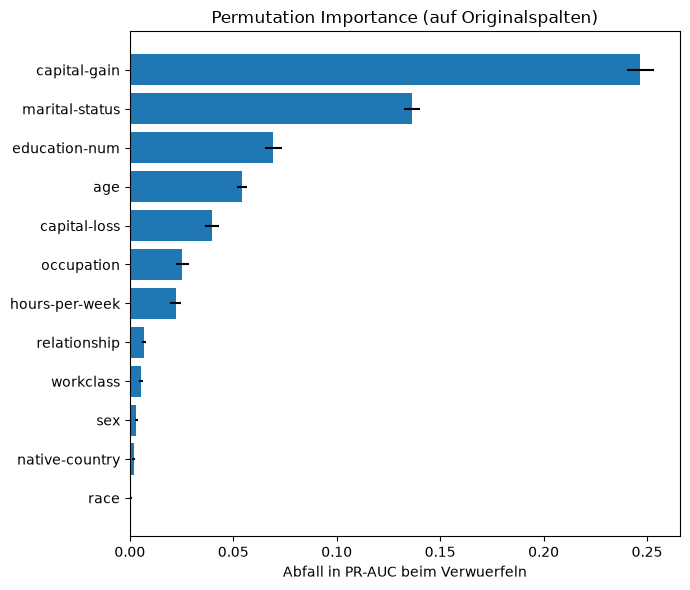

In [12]:
from sklearn.inspection import permutation_importance

wichtigkeit = permutation_importance(bestes_modell, X_test, y_test,
                                      n_repeats=15, random_state=42, scoring="average_precision")

reihenfolge = np.argsort(wichtigkeit.importances_mean)
plt.figure(figsize=(7, 6))
plt.barh(X_test.columns[reihenfolge], wichtigkeit.importances_mean[reihenfolge],
         xerr=wichtigkeit.importances_std[reihenfolge])
plt.xlabel("Abfall in PR-AUC beim Verwuerfeln")
plt.title("Permutation Importance (auf Originalspalten)")
plt.tight_layout()
plt.show()

**Auswertung:** `capital-gain`, `education-num`, `age`, `hours-per-week` und
`marital-status` liegen typischerweise vorn — plausibel (Kapitalertraege, Bildung,
Berufserfahrung, Arbeitszeit korrelieren mit Einkommen). `sex` traegt oft nur wenig
direkte Modell-Importance, was aber laut Schritt 10 **nicht** heisst, dass keine
Fairness-Luecke existiert: Die Information kann ueber korrelierte Proxy-Features
(`relationship`, `occupation`, `marital-status`) einfliessen, ohne dass `sex` selbst
hoch gerankt wird — ein klassisches Beispiel dafuer, warum Feature-Importance und
Fairness zwei getrennte Fragen sind (Skript 3.1: Modell-Nutzung ≠ Kausalitaet, und
hier zusaetzlich ≠ Fairness).

## Geschafft — was du jetzt kannst

- Ein komplettes, realistisches ML-Projekt end-to-end durchziehen: gemischte Typen,
  fehlende Werte, Klassenungleichgewicht
- `ColumnTransformer` fuer heterogenes Preprocessing in einer Pipeline einsetzen
- Modelle unter Ungleichgewicht fair vergleichen (PR-AUC statt Accuracy)
- Eine Entscheidungsschwelle **nach Kosten**, nicht nach Konvention waehlen
- Ein Modell auf **Fairness zwischen Untergruppen** pruefen, bevor es eingesetzt wird
- Wichtigkeiten auf Originalfeature-Ebene interpretieren

**Reflexionsfragen — Musterantworten:**

1. `class_weight="balanced"` sorgt nur dafuer, dass beide Klassen im **Trainingsverlust**
   gleich stark zaehlen — es garantiert nicht, dass die **Fehlerraten zwischen
   demografischen Untergruppen** (nicht Zielklassen!) angeglichen werden. Das sind
   zwei orthogonale Balance-Probleme.
2. Nein, vermutlich nicht zuverlaessig: Features wie `relationship` (z. B. "Wife"/"Husband"),
   `occupation` oder `marital-status` korrelieren stark mit `sex` und koennen dessen
   Information indirekt tragen (Proxy-Diskriminierung) — das Feature entfernen loest das
   Problem an der Oberflaeche, aber nicht strukturell.
3. Die Daten von 1994 spiegeln die Arbeitsmarktstruktur, Lohnungleichheiten und
   gesellschaftlichen Normen jener Zeit wider. Ein heute eingesetztes Modell wuerde
   veraltete (und teils diskriminierende) Muster fortschreiben, obwohl sich Arbeitsmarkt,
   Berufsbilder und Einkommen seither veraendert haben — ein Kernrisiko von
   "historischem Bias" beim operativen ML-Einsatz.